# Train DenseNet121_FCSSAM On Dataset Ver1

TensorFlow notebook for Kaggle GPU/P100.

Dataset path:
`/kaggle/input/datasets/thuanminh1310/dataset-verson1`

Classes:
- `normal`
- `pneumonia`
- `effusion`

Both model notebooks use the same input pipeline for fair comparison.


In [1]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

SEED = 42
MODEL_KEY = "densenet121_fcssam"
DISPLAY_NAME = "DenseNet121_FCSSAM_DatasetVer1_TF_P100"
CLASS_NAMES = ["normal", "pneumonia", "effusion"]
CLASS_TO_INDEX = {name: idx for idx, name in enumerate(CLASS_NAMES)}

DATASET_ROOT_CANDIDATES = [
    Path("/kaggle/input/datasets/thuanminh1310/dataset-verson1"),
    Path("/kaggle/input/dataset-verson1"),
    Path("/kaggle/working/pbl4_main_effusion_no_pneumonia_datasets"),
]

TRAIN_MANIFEST_NAME = "main_train_2_1_1_effusion_no_pneumonia.csv"
VAL_MANIFEST_NAME = "main_val_70_15_15_effusion_no_pneumonia.csv"
TEST_MANIFEST_NAME = "main_test_70_15_15_effusion_no_pneumonia.csv"

IMAGE_SIZE = 256
BATCH_SIZE = 16
EPOCHS = 22
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 1e-4
LABEL_SMOOTHING = 0.03
EFFUSION_BOOST = 1.20
PATIENCE = 6
DROPOUT_RATE = 0.0

OUTPUT_DIR = Path("/kaggle/working/train_densenet121_fcssam_dataset_ver1_tf_p100")
ARTIFACT_DIR = OUTPUT_DIR / "artifacts"
FIGURE_DIR = OUTPUT_DIR / "figures"
MODEL_DIR = OUTPUT_DIR / "models" / MODEL_KEY
PREDICTION_DIR = OUTPUT_DIR / "predictions"
for directory in [OUTPUT_DIR, ARTIFACT_DIR, FIGURE_DIR, MODEL_DIR, PREDICTION_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print("Configuration")
print(f"- model: {MODEL_KEY}")
print(f"- classes: {CLASS_NAMES}")
print(f"- image_size: {IMAGE_SIZE}")
print(f"- batch_size: {BATCH_SIZE}")
print(f"- output_dir: {OUTPUT_DIR}")


2026-05-28 08:16:54.305039: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779956214.513805      23 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779956214.574513      23 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779956215.073109      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779956215.073144      23 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779956215.073147      23 computation_placer.cc:177] computation placer alr

Configuration
- model: densenet121_fcssam
- classes: ['normal', 'pneumonia', 'effusion']
- image_size: 256
- batch_size: 16
- output_dir: /kaggle/working/train_densenet121_fcssam_dataset_ver1_tf_p100


In [2]:
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


seed_everything(SEED)

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)
for gpu in gpus:
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except Exception as exc:
        print("Could not set memory growth:", exc)

try:
    tf.keras.mixed_precision.set_global_policy("mixed_float16")
    print("Mixed precision policy:", tf.keras.mixed_precision.global_policy())
except Exception as exc:
    print("Mixed precision not enabled:", exc)


GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]
Mixed precision policy: <DTypePolicy "mixed_float16">


In [3]:
def find_manifest_dir():
    checked = []
    for root in DATASET_ROOT_CANDIDATES:
        checked.append(str(root))
        if not root.exists():
            continue
        candidates = [root / "manifests", root]
        candidates.extend(path for path in root.rglob("manifests") if path.is_dir())
        for candidate in candidates:
            if (candidate / TRAIN_MANIFEST_NAME).exists():
                return candidate
    raise FileNotFoundError("Could not find manifest directory. Checked: " + ", ".join(checked))


def load_manifest(path):
    df = pd.read_csv(path)
    required = ["resolved_path", "class_name", "class_index"]
    missing = [column for column in required if column not in df.columns]
    if missing:
        raise KeyError(f"Missing columns in {path}: {missing}")
    df = df.loc[df["class_name"].isin(CLASS_NAMES)].copy().reset_index(drop=True)
    df["class_index"] = df["class_name"].map(CLASS_TO_INDEX).astype(np.int32)
    df["resolved_path"] = df["resolved_path"].astype(str)
    missing_paths = ~df["resolved_path"].map(lambda value: Path(value).exists())
    if missing_paths.any():
        examples = df.loc[missing_paths, "resolved_path"].head(8).tolist()
        raise FileNotFoundError(
            "Some image paths in the manifest do not exist. Add the original NIH and Chest-Xray-Pneumonia Kaggle datasets as inputs. "
            f"Examples: {examples}"
        )
    return df


MANIFEST_DIR = find_manifest_dir()
train_df = load_manifest(MANIFEST_DIR / TRAIN_MANIFEST_NAME)
val_df = load_manifest(MANIFEST_DIR / VAL_MANIFEST_NAME)
test_df = load_manifest(MANIFEST_DIR / TEST_MANIFEST_NAME)

print("MANIFEST_DIR:", MANIFEST_DIR)
display(pd.DataFrame({
    "split": ["train", "val", "test"],
    "samples": [len(train_df), len(val_df), len(test_df)],
}))

counts_df = pd.DataFrame({
    "class_name": CLASS_NAMES,
    "train": train_df["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0).values,
    "val": val_df["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0).values,
    "test": test_df["class_name"].value_counts().reindex(CLASS_NAMES, fill_value=0).values,
})
counts_df.to_csv(ARTIFACT_DIR / "dataset_counts.csv", index=False)
display(counts_df)


MANIFEST_DIR: /kaggle/input/datasets/thuanminh1310/dataset-verson1/pbl4_main_effusion_no_pneumonia_datasets/manifests


,split,samples
0,train,13788
1,val,2927
2,test,2580


,class_name,train,val,test
0,normal,6894,2049,1806
1,pneumonia,3447,439,387
2,effusion,3447,439,387


In [4]:
train_class_counts = train_df["class_index"].value_counts().sort_index().reindex(range(len(CLASS_NAMES)), fill_value=0).astype(float)
base_class_weights = len(train_df) / (len(CLASS_NAMES) * train_class_counts.values)
base_class_weights = base_class_weights / base_class_weights.mean()
base_class_weights[CLASS_TO_INDEX["effusion"]] *= EFFUSION_BOOST
base_class_weights = base_class_weights / base_class_weights.mean()

class_weight_df = pd.DataFrame({
    "class_name": CLASS_NAMES,
    "train_count": train_class_counts.values.astype(int),
    "class_weight": base_class_weights,
})
class_weight_df.to_csv(ARTIFACT_DIR / "class_weights.csv", index=False)
display(class_weight_df)


,class_name,train_count,class_weight
0,normal,6894,0.555556
1,pneumonia,3447,1.111111
2,effusion,3447,1.333333


In [5]:
AUTOTUNE = tf.data.AUTOTUNE


def build_augmenter():
    return tf.keras.Sequential([
        tf.keras.layers.RandomTranslation(0.015, 0.015),
        tf.keras.layers.RandomZoom(0.03, 0.03),
        tf.keras.layers.RandomFlip("horizontal"),
    ], name="xray_augmenter_dataset_ver1")


AUGMENTER = build_augmenter()


def enhance_xray_contrast(image):
    image = tf.cast(image, tf.float32) / 255.0
    image_min = tf.reduce_min(image, axis=[0, 1, 2], keepdims=True)
    image_max = tf.reduce_max(image, axis=[0, 1, 2], keepdims=True)
    image = (image - image_min) / tf.maximum(image_max - image_min, 1e-6)
    image = tf.image.adjust_gamma(image, gamma=0.95)
    return tf.clip_by_value(image * 255.0, 0.0, 255.0)


def common_preprocess_input(image):
    image = tf.cast(image, tf.float32)
    image = image[..., ::-1]  # RGB -> BGR
    mean = tf.constant([103.939, 116.779, 123.680], dtype=tf.float32)
    return image - mean


def decode_resize_preprocess(path, label, training=False):
    image_bytes = tf.io.read_file(path)
    image = tf.io.decode_image(image_bytes, channels=1, expand_animations=False)
    image.set_shape([None, None, 1])
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE], method=tf.image.ResizeMethod.BILINEAR)
    image = enhance_xray_contrast(image)
    image = tf.image.grayscale_to_rgb(image)
    if training:
        image = AUGMENTER(image, training=True)
    image = common_preprocess_input(image)
    return image, tf.cast(label, tf.int32)


def make_dataset(df, batch_size, training=False):
    paths = df["resolved_path"].astype(str).values
    labels = df["class_index"].astype(np.int32).values
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(df), seed=SEED, reshuffle_each_iteration=True)
    ds = ds.map(lambda x, y: decode_resize_preprocess(x, y, training=training), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    return ds.prefetch(AUTOTUNE)


train_ds = make_dataset(train_df, BATCH_SIZE, training=True)
val_ds = make_dataset(val_df, BATCH_SIZE, training=False)
test_ds = make_dataset(test_df, BATCH_SIZE, training=False)

sample_images, sample_labels = next(iter(train_ds.take(1)))
print("sample batch:", sample_images.shape, sample_labels.shape, sample_images.dtype)


I0000 00:00:1779956300.259289      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779956300.265426      23 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


sample batch: (16, 256, 256, 3) (16,) <dtype: 'float32'>


In [6]:
layers = tf.keras.layers


@tf.keras.utils.register_keras_serializable()
class ChannelMean(layers.Layer):
    def call(self, inputs):
        return tf.reduce_mean(inputs, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable()
class ChannelMax(layers.Layer):
    def call(self, inputs):
        return tf.reduce_max(inputs, axis=-1, keepdims=True)


@tf.keras.utils.register_keras_serializable()
class FuzzyChannelSelection(layers.Layer):
    def __init__(self, keep_ratio=0.80, **kwargs):
        super().__init__(**kwargs)
        self.keep_ratio = keep_ratio

    def build(self, input_shape):
        channels = int(input_shape[-1])
        self.keep_channels = max(1, int(np.ceil(channels * self.keep_ratio)))
        self.alpha = self.add_weight(
            name="alpha",
            shape=(channels,),
            initializer=tf.keras.initializers.RandomUniform(minval=-0.05, maxval=0.05),
            trainable=True,
        )
        self.richards_A = self.add_weight(name="richards_A", shape=(), initializer=tf.keras.initializers.Constant(0.541324854612918), trainable=True)
        self.richards_Q = self.add_weight(name="richards_Q", shape=(), initializer=tf.keras.initializers.Constant(0.541324854612918), trainable=True)
        self.richards_mu = self.add_weight(name="richards_mu", shape=(), initializer="zeros", trainable=True)
        super().build(input_shape)

    def call(self, inputs):
        A = tf.nn.softplus(self.richards_A) + 1e-6
        Q = tf.nn.softplus(self.richards_Q) + 1e-6
        scores = 1.0 / (1.0 + tf.exp(A - Q * (self.alpha - self.richards_mu)))
        topk = tf.math.top_k(scores, k=self.keep_channels, sorted=True)
        selected = tf.gather(inputs, topk.indices, axis=-1)
        selected_scores = tf.reshape(topk.values, [1, 1, 1, self.keep_channels])
        return selected * selected_scores

    def get_config(self):
        config = super().get_config()
        config.update({"keep_ratio": self.keep_ratio})
        return config


def create_channel_attention_mask(feature_map, ratio=8, prefix="cam"):
    channels = int(feature_map.shape[-1])
    reduced_channels = max(channels // ratio, 8)
    shared_dense_1 = layers.Dense(reduced_channels, activation="relu", use_bias=False, name=f"{prefix}_dense1")
    shared_dense_2 = layers.Dense(channels, use_bias=False, name=f"{prefix}_dense2")
    avg_pool = shared_dense_2(shared_dense_1(layers.GlobalAveragePooling2D(name=f"{prefix}_gap")(feature_map)))
    max_pool = shared_dense_2(shared_dense_1(layers.GlobalMaxPooling2D(name=f"{prefix}_gmp")(feature_map)))
    attention = layers.Add(name=f"{prefix}_add")([avg_pool, max_pool])
    attention = layers.Activation("sigmoid", name=f"{prefix}_sigmoid")(attention)
    return layers.Reshape((1, 1, channels), name=f"{prefix}_reshape")(attention)


def apply_sc_layers(feature_map, channels, prefix):
    x = layers.SeparableConv2D(channels, 1, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal", name=f"{prefix}_sc1")(feature_map)
    x = layers.SeparableConv2D(channels, 3, padding="same", depthwise_initializer="he_normal", pointwise_initializer="he_normal", name=f"{prefix}_sc2")(x)
    x = layers.BatchNormalization(name=f"{prefix}_bn")(x)
    return layers.ReLU(name=f"{prefix}_relu")(x)


def create_spatial_attention_branch(feature_map, cam_mask, pool_mode, prefix):
    channels = int(feature_map.shape[-1])
    sc_features = apply_sc_layers(feature_map, channels, prefix)
    channel_specific = layers.Multiply(name=f"{prefix}_channel_mul")([sc_features, cam_mask])
    if pool_mode == "avg":
        pooled = ChannelMean(name=f"{prefix}_pool")(channel_specific)
    elif pool_mode == "max":
        pooled = ChannelMax(name=f"{prefix}_pool")(channel_specific)
    else:
        raise ValueError(f"Unsupported pool_mode: {pool_mode}")
    spatial_attention = layers.Conv2D(1, 7, padding="same", activation="sigmoid", kernel_initializer="he_normal", name=f"{prefix}_spatial_conv")(pooled)
    return layers.Multiply(name=f"{prefix}_spatial_mul")([channel_specific, spatial_attention])


def create_fcssam_module(feature_map, attention_ratio=8, keep_ratio=0.80, prefix="fcssam"):
    cam_mask = create_channel_attention_mask(feature_map, ratio=attention_ratio, prefix=f"{prefix}_cam")
    sam_avg = create_spatial_attention_branch(feature_map, cam_mask, pool_mode="avg", prefix=f"{prefix}_samavg")
    sam_max = create_spatial_attention_branch(feature_map, cam_mask, pool_mode="max", prefix=f"{prefix}_sammax")
    concat_features = layers.Concatenate(name=f"{prefix}_concat")([sam_avg, sam_max])
    selected_features = FuzzyChannelSelection(keep_ratio=keep_ratio, name=f"{prefix}_select")(concat_features)
    return selected_features
def build_densenet121_fcssam(input_shape):
    inputs = layers.Input(shape=input_shape, name="image")
    backbone = tf.keras.applications.DenseNet121(include_top=False, weights="imagenet", input_tensor=inputs)
    fcssam_output = create_fcssam_module(backbone.output, attention_ratio=8, keep_ratio=0.80, prefix="overall_fcssam")
    x = layers.GlobalAveragePooling2D(name="densenet_gap")(fcssam_output)
    outputs = layers.Dense(len(CLASS_NAMES), activation="softmax", dtype="float32", name="class_probs")(x)
    return tf.keras.Model(inputs=inputs, outputs=outputs, name="densenet121_fcssam_dataset_ver1")


if MODEL_KEY == "densenet121_fcssam":
    model = build_densenet121_fcssam((IMAGE_SIZE, IMAGE_SIZE, 3))
else:
    raise ValueError(f"Unsupported MODEL_KEY: {MODEL_KEY}")

model.summary()


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet121_fcssam_dataset_ver1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ image (InputLayer)  │ (None, 256, 256,  │          0 │ -                 │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d      │ (None, 262, 262,  │          0 │ image[0][0]       │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,408 │ zero_padding2d[0… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ zero_padding2d_1    │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1               │ (None, 64, 64,    │          0 │ zero_padding2d_1… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │        256 │ pool1[0][0]       │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_relu │ (None, 64, 64,    │          0 │ conv2_block1_0_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      8,192 │ conv2_block1_0_r… │
│ (Conv2D)            │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        512 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,864 │ conv2_block1_1_r… │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_concat │ (None, 64, 64,    │          0 │ pool1[0][0],      │
│ (Concatenate)       │ 96)               │            │ conv2_block1_2_c… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_bn   │ (None, 64, 64,    │        384 │ conv2_block1_con… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_0_relu │ (None, 64, 64,    │          0 │ conv2_block2_0_b… │
│ (Activation)        │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block2_1_conv │ (None, 64, 64,    │     12,288 │ conv2_block2_0_r

 Total params: 11,533,791 (44.00 MB)

 Trainable params: 11,446,047 (43.66 MB)

 Non-trainable params: 87,744 (342.75 KB)

In [7]:
def build_weighted_smoothed_sparse_categorical_crossentropy(class_weights, label_smoothing=0.03):
    class_weights_tensor = tf.constant(class_weights, dtype=tf.float32)
    num_classes = tf.constant(len(class_weights), dtype=tf.float32)

    def loss_fn(y_true, y_pred):
        y_true_int = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        y_true_one_hot = tf.one_hot(y_true_int, depth=len(class_weights), dtype=tf.float32)
        if label_smoothing > 0:
            smooth_pos = 1.0 - label_smoothing
            smooth_neg = label_smoothing / (num_classes - 1.0)
            y_true_one_hot = y_true_one_hot * smooth_pos + (1.0 - y_true_one_hot) * smooth_neg
        y_pred = tf.clip_by_value(tf.cast(y_pred, tf.float32), 1e-7, 1.0 - 1e-7)
        per_sample_loss = -tf.reduce_sum(y_true_one_hot * tf.math.log(y_pred), axis=-1)
        sample_weights = tf.gather(class_weights_tensor, y_true_int)
        return tf.reduce_mean(per_sample_loss * sample_weights)

    return loss_fn


try:
    optimizer = tf.keras.optimizers.AdamW(learning_rate=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
except Exception:
    optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=build_weighted_smoothed_sparse_categorical_crossentropy(base_class_weights, LABEL_SMOOTHING),
    metrics=[tf.keras.metrics.SparseCategoricalAccuracy(name="accuracy")],
)

callbacks = [
    tf.keras.callbacks.ModelCheckpoint(MODEL_DIR / "best.keras", monitor="val_loss", save_best_only=True, mode="min"),
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True, mode="min"),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2, min_lr=1e-7, mode="min"),
    tf.keras.callbacks.CSVLogger(MODEL_DIR / "history.csv"),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
)

model.save(MODEL_DIR / "final.keras")
pd.DataFrame(history.history).to_csv(MODEL_DIR / "history_final.csv", index=False)


Epoch 1/22


I0000 00:00:1779956374.974331      71 service.cc:152] XLA service 0x7f038c0643e0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779956374.974379      71 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779956374.974385      71 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779956389.210837      71 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1779956536.662645      71 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


862/862 ━━━━━━━━━━━━━━━━━━━━ 678s 512ms/step - accuracy: 0.4296 - loss: 0.7997 - val_accuracy: 0.5319 - val_loss: 0.5882 - learning_rate: 5.0000e-05
Epoch 2/22
862/862 ━━━━━━━━━━━━━━━━━━━━ 239s 277ms/step - accuracy: 0.8273 - loss: 0.4812 - val_accuracy: 0.8196 - val_loss: 0.3542 - learning_rate: 5.0000e-05
Epoch 3/22
862/862 ━━━━━━━━━━━━━━━━━━━━ 239s 277ms/step - accuracy: 0.8636 - loss: 0.3683 - val_accuracy: 0.8688 - val_loss: 0.3154 - learning_rate: 5.0000e-05
Epoch 4/22
862/862 ━━━━━━━━━━━━━━━━━━━━ 236s 273ms/step - accuracy: 0.8767 - loss: 0.3385 - val_accuracy: 0.8261 - val_loss: 0.3514 - learning_rate: 5.0000e-05
Epoch 5/22
862/862 ━━━━━━━━━━━━━━━━━━━━ 239s 277ms/step - accuracy: 0.8872 - loss: 0.3220 - val_accuracy: 0.8719 - val_loss: 0.3153 - learning_rate: 5.0000e-05
Epoch 6/22
862/862 ━━━━━━━━━━━━━━━━━━━━ 236s 274ms/step - accuracy: 0.9041 - loss: 0.2948 - val_accuracy: 0.8671 - val_loss: 0.3321 - learning_rate: 2.5000e-05
Epoch 7/22
862/862 ━━━━━━━━━━━━━━━━━━━━ 236s 274ms/

183/183 ━━━━━━━━━━━━━━━━━━━━ 45s 172ms/step
162/162 ━━━━━━━━━━━━━━━━━━━━ 35s 218ms/step


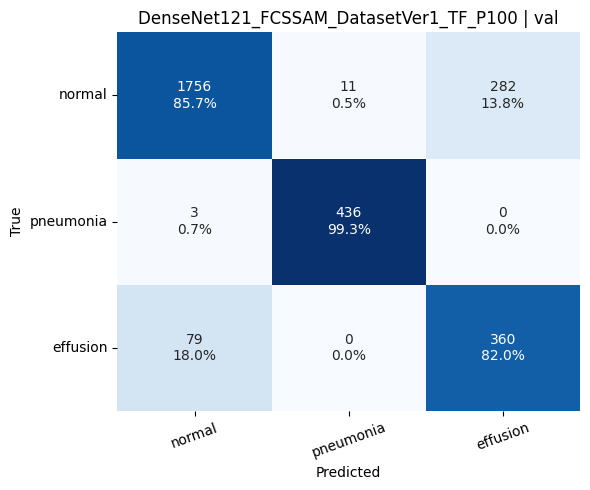

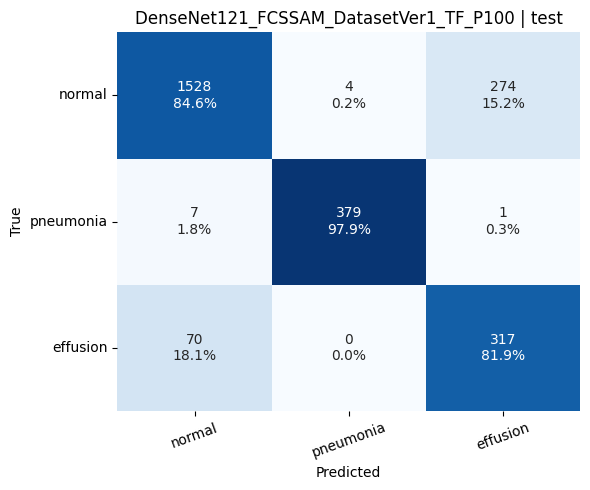

,model_key,split,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,macro_auc_ovr
0,densenet121_fcssam,val,0.871882,0.830508,0.890072,0.851258,0.880007,0.95694
1,densenet121_fcssam,test,0.862016,0.825685,0.881506,0.842647,0.871950,0.95894


,model_key,split,class_name,precision,recall,f1,support,auc_ovr
0,densenet121_fcssam,val,normal,0.955386,0.857003,0.903525,2049,0.949964
1,densenet121_fcssam,val,pneumonia,0.975391,0.993166,0.984199,439,0.999838
2,densenet121_fcssam,val,effusion,0.560748,0.820046,0.666050,439,0.921019
3,densenet121_fcssam,test,normal,0.952025,0.846069,0.895925,1806,0.950924
4,densenet121_fcssam,test,pneumonia,0.989556,0.979328,0.984416,387,0.999767
5,densenet121_fcssam,test,effusion,0.535473,0.819121,0.647600,387,0.926127


Saved artifacts to: /kaggle/working/train_densenet121_fcssam_dataset_ver1_tf_p100/artifacts


In [8]:
def predict_dataframe(model_obj, df, ds):
    probs = model_obj.predict(ds, verbose=1).astype(np.float32)
    y_true = df["class_index"].astype(np.int32).values
    y_pred = np.argmax(probs, axis=1).astype(np.int32)
    return probs, y_true, y_pred


def compute_per_class_auc(y_true, probs):
    auc_map = {}
    for idx, class_name in enumerate(CLASS_NAMES):
        binary_true = (y_true == idx).astype(int)
        if len(np.unique(binary_true)) < 2:
            auc_map[class_name] = np.nan
        else:
            auc_map[class_name] = roc_auc_score(binary_true, probs[:, idx])
    return auc_map


def evaluate_split(y_true, probs, y_pred, split_name):
    auc_map = compute_per_class_auc(y_true, probs)
    class_report = classification_report(y_true, y_pred, target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    class_rows = []
    for class_name in CLASS_NAMES:
        row = class_report[class_name]
        class_rows.append({
            "model_key": MODEL_KEY,
            "split": split_name,
            "class_name": class_name,
            "precision": float(row["precision"]),
            "recall": float(row["recall"]),
            "f1": float(row["f1-score"]),
            "support": int(row["support"]),
            "auc_ovr": float(auc_map[class_name]) if not np.isnan(auc_map[class_name]) else np.nan,
        })
    summary = {
        "model_key": MODEL_KEY,
        "split": split_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_precision": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_recall": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "weighted_f1": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "macro_auc_ovr": float(np.nanmean(list(auc_map.values()))),
    }
    return pd.DataFrame([summary]), pd.DataFrame(class_rows)


def save_prediction_frame(df, probs, y_pred, split_name):
    pred_df = df[[column for column in ["sample_id", "source", "resolved_path", "class_name", "class_index", "finding_labels_raw"] if column in df.columns]].copy()
    pred_df["pred_class_index"] = y_pred
    pred_df["pred_class_name"] = [CLASS_NAMES[idx] for idx in y_pred]
    for idx, class_name in enumerate(CLASS_NAMES):
        pred_df[f"prob_{class_name}"] = probs[:, idx]
    pred_df.to_csv(PREDICTION_DIR / f"{MODEL_KEY}_{split_name}_predictions.csv", index=False)
    return pred_df


def plot_confusion(y_true, y_pred, split_name):
    cm = confusion_matrix(y_true, y_pred, labels=list(range(len(CLASS_NAMES))))
    cm_norm = cm / np.maximum(cm.sum(axis=1, keepdims=True), 1)
    annotations = np.empty_like(cm, dtype=object)
    for row_idx in range(cm.shape[0]):
        for col_idx in range(cm.shape[1]):
            annotations[row_idx, col_idx] = f"{cm[row_idx, col_idx]}\n{cm_norm[row_idx, col_idx]:.1%}"
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_norm, annot=annotations, fmt="", cmap="Blues", vmin=0.0, vmax=1.0, cbar=False, ax=ax)
    ax.set_title(f"{DISPLAY_NAME} | {split_name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_xticklabels(CLASS_NAMES, rotation=20)
    ax.set_yticklabels(CLASS_NAMES, rotation=0)
    plt.tight_layout()
    path = FIGURE_DIR / f"{MODEL_KEY}_{split_name}_confusion.png"
    plt.savefig(path, dpi=200, bbox_inches="tight")
    plt.show()
    return path


val_probs, y_val_true, y_val_pred = predict_dataframe(model, val_df, val_ds)
test_probs, y_test_true, y_test_pred = predict_dataframe(model, test_df, test_ds)

val_summary_df, val_class_df = evaluate_split(y_val_true, val_probs, y_val_pred, "val")
test_summary_df, test_class_df = evaluate_split(y_test_true, test_probs, y_test_pred, "test")
summary_df = pd.concat([val_summary_df, test_summary_df], ignore_index=True)
class_df = pd.concat([val_class_df, test_class_df], ignore_index=True)

summary_df.to_csv(ARTIFACT_DIR / f"{MODEL_KEY}_summary_metrics.csv", index=False)
class_df.to_csv(ARTIFACT_DIR / f"{MODEL_KEY}_class_report.csv", index=False)
save_prediction_frame(val_df, val_probs, y_val_pred, "val")
save_prediction_frame(test_df, test_probs, y_test_pred, "test")
plot_confusion(y_val_true, y_val_pred, "val")
plot_confusion(y_test_true, y_test_pred, "test")

display(summary_df)
display(class_df)
print("Saved artifacts to:", ARTIFACT_DIR)
